## Install Dependencies

In [1]:
!pip install kaggle -q

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2
from skimage.metrics import structural_similarity as ssim

# Device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected — training will be slow. Enable GPU in Runtime settings.')

Device: cpu



##  Dataset Download



In [13]:
import os

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Mars Rover Project/mars_terrain'

print(f'Dataset found at: {DATA_PATH}')
print('Contents:')
for item in os.listdir(DATA_PATH):
    print(f'  {item}')

Dataset found at: /content/drive/MyDrive/Colab Notebooks/Mars Rover Project/mars_terrain
Contents:
  Auburn_1


In [14]:
# Show folder structure
print('\nDataset structure:')
for root, dirs, files_list in os.walk(DATA_PATH):
    level = root.replace(DATA_PATH, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files_list[:3]:
            print(f'{indent}  {f}')
        if len(files_list) > 3:
            print(f'{indent}  ... ({len(files_list)} files total)')



Dataset structure:
mars_terrain/
  Auburn_1/
    other/
    bright dune/
    crater/
    spider/
    slope streak/
    dark dune/
    swiss cheese/
    impact ejecta/



##  Dataset Configuration



In [ ]:
# ── Data paths
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/Mars Rover Project/mars_terrain'
DATA_ROOT = os.path.join(BASE_PATH, 'Auburn_1')  # Classes live inside Auburn_1/

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
NUM_CLASSES = len(CLASS_NAMES)

print(f'Data root:   {DATA_ROOT}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# Count images per class
print('\nImages per class:')
total_images = 0
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATA_ROOT, cls)
    count = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total_images += count
    print(f'  {cls:<20} {count:>5} images')
print(f'  {"TOTAL":<20} {total_images:>5} images')

#  Terrain cost mapping
# Maps each dataset class to a navigation cost for the A* planner
# Safe=1, Rocky=5, Hazardous=inf
TERRAIN_COST_MAP = {
    'bright dune':   5,            # Rocky — traversable but slow
    'crater':        float('inf'), # Hazardous — impassable
    'dark dune':     5,            # Rocky — traversable but slow
    'impact ejecta': float('inf'), # Hazardous — unstable surface
    'other':         1,            # Safe — flat traversable ground
    'slope streak':  5,            # Rocky — risky gradient
    'spider':        float('inf'), # Hazardous — irregular terrain
    'swiss cheese':  float('inf'), # Hazardous — pit-like surface
}

# Human-readable labels for navigation
TERRAIN_NAV_LABEL = {
    'bright dune':   'Rocky',
    'crater':        'Hazardous',
    'dark dune':     'Rocky',
    'impact ejecta': 'Hazardous',
    'other':         'Safe',
    'slope streak':  'Rocky',
    'spider':        'Hazardous',
    'swiss cheese':  'Hazardous',
}

print('\nTerrain cost mapping:')
print(f'  {"Class":<20} {"Nav Label":<12} {"Cost"}')
print('  ' + '-' * 42)
for cls in CLASS_NAMES:
    cost  = TERRAIN_COST_MAP.get(cls, 1)
    label = TERRAIN_NAV_LABEL.get(cls, 'Safe')
    cost_str = 'inf' if cost == float('inf') else str(cost)
    print(f'  {cls:<20} {label:<12} {cost_str}')


Data root:   /content/drive/MyDrive/Colab Notebooks/Mars Rover Project/mars_terrain/Auburn_1
Classes (8): ['bright dune', 'crater', 'dark dune', 'impact ejecta', 'other', 'slope streak', 'spider', 'swiss cheese']

Images per class:
  bright dune            591 images
  crater                1056 images
  dark dune              210 images
  impact ejecta           45 images
  other                 3645 images
  slope streak           329 images
  spider                  60 images
  swiss cheese           217 images
  TOTAL                 6153 images

Terrain cost mapping:
  Class                Nav Label    Cost
  ------------------------------------------
  bright dune          Rocky        5
  crater               Hazardous    inf
  dark dune            Rocky        5
  impact ejecta        Hazardous    inf
  other                Safe         1
  slope streak         Rocky        5
  spider               Hazardous    inf
  swiss cheese         Hazardous    inf


## Dataset Exploration

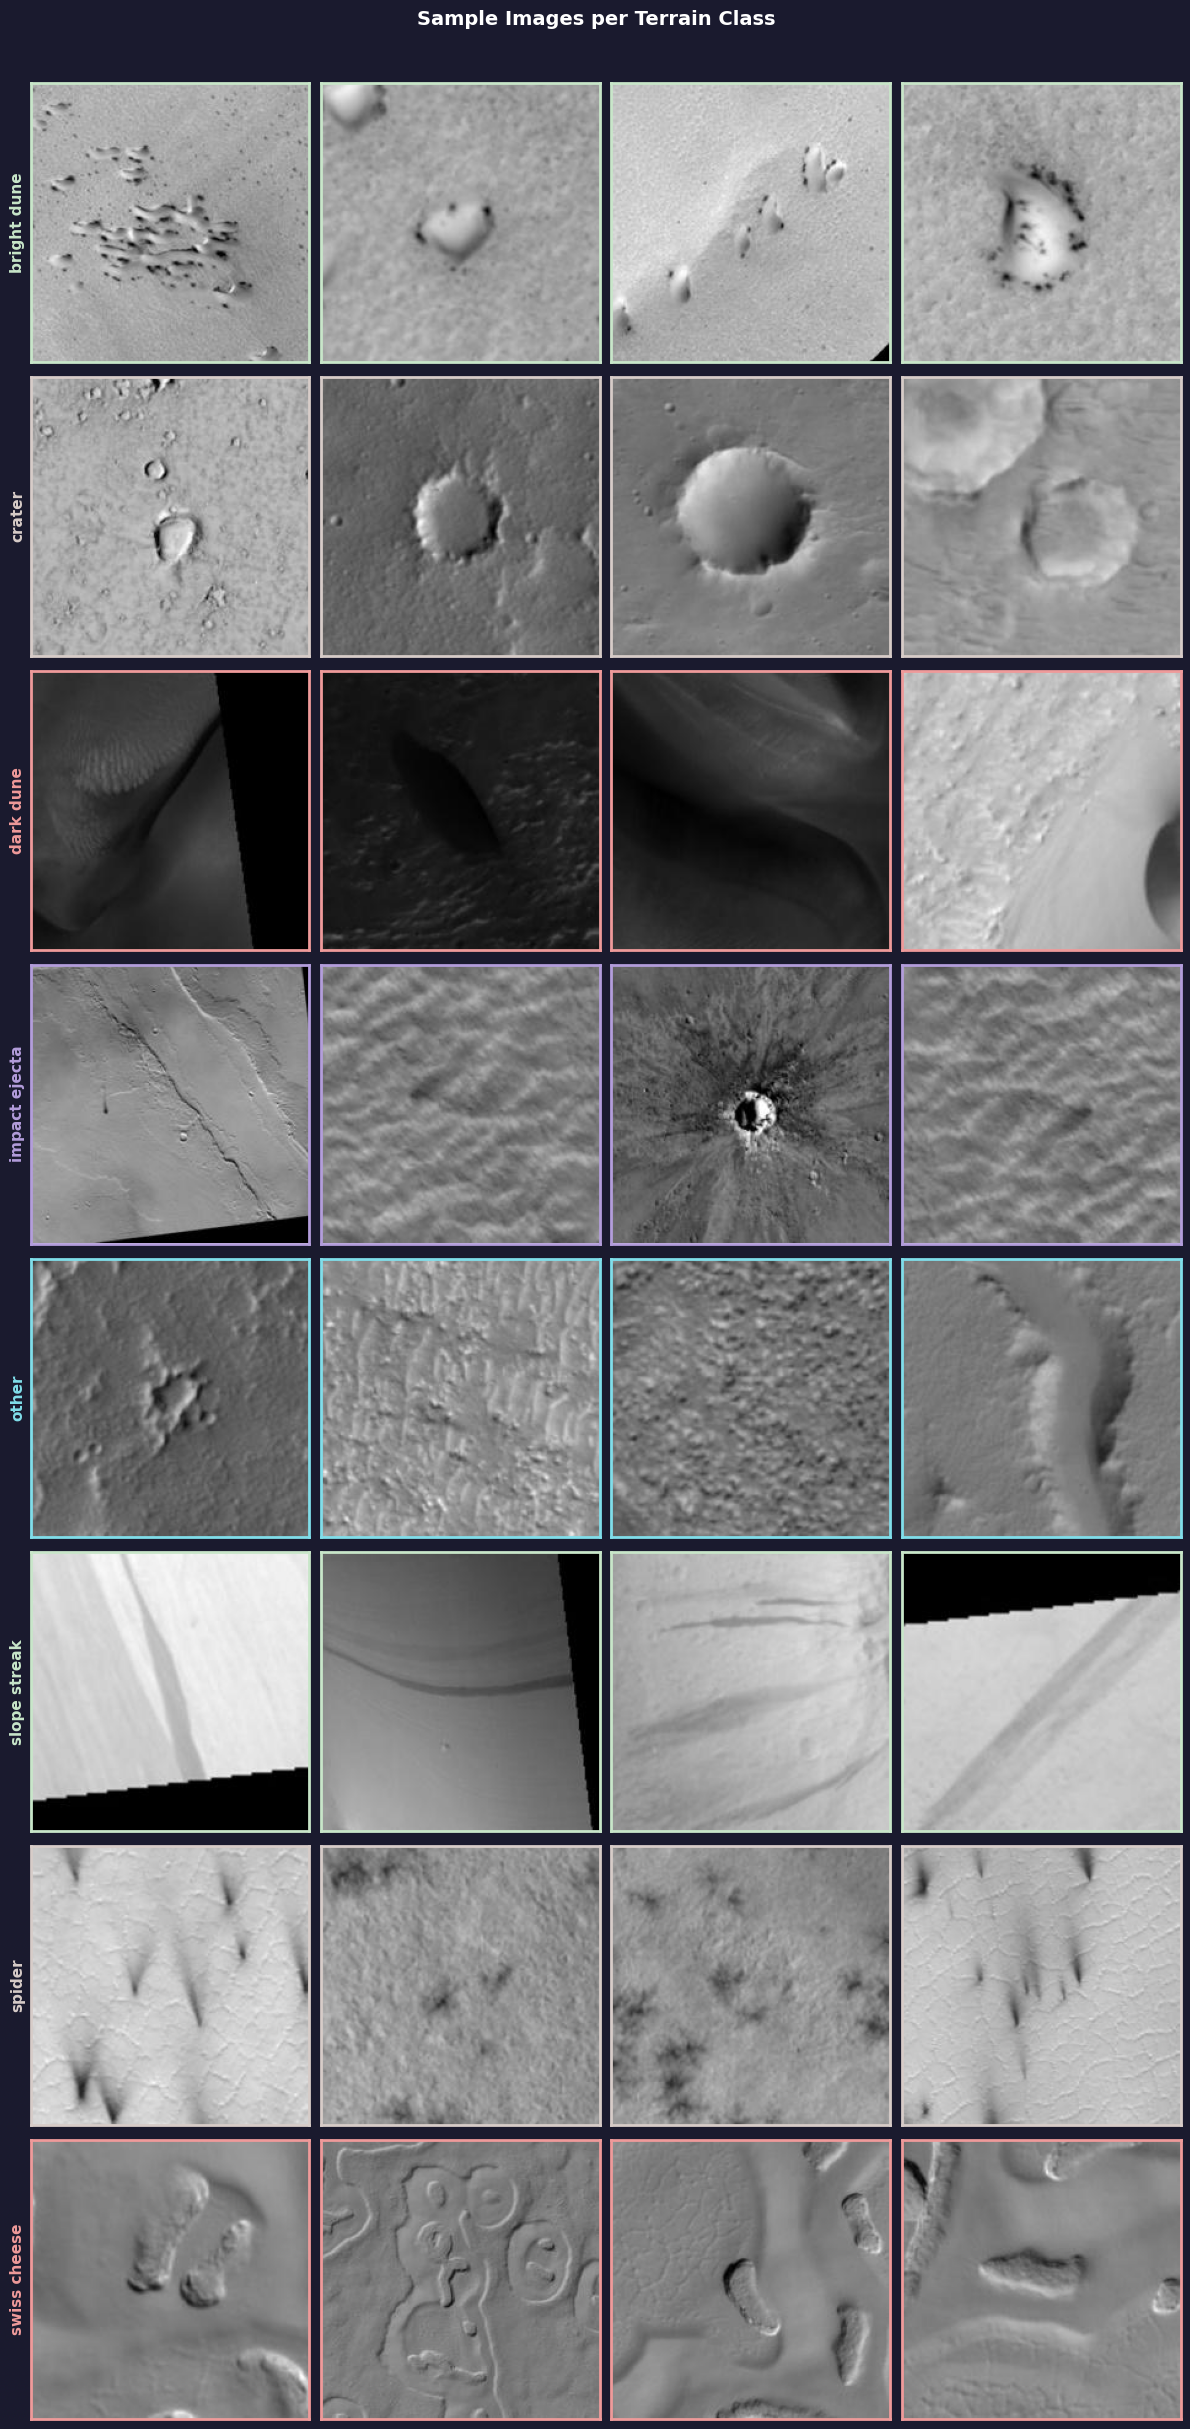

In [ ]:
#  Visualise sample images per class
SAMPLES_PER_CLASS = 4
CLASS_COLOURS = ['#C8E6C9', '#D7CCC8', '#EF9A9A', '#B39DDB', '#80DEEA']

fig, axes = plt.subplots(
    NUM_CLASSES, SAMPLES_PER_CLASS,
    figsize=(SAMPLES_PER_CLASS * 3, NUM_CLASSES * 3)
)
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('Sample Images per Terrain Class', color='white',
             fontsize=14, fontweight='bold', y=1.01)

if NUM_CLASSES == 1:
    axes = [axes]

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATA_ROOT, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    np.random.seed(42)
    samples = np.random.choice(img_files, min(SAMPLES_PER_CLASS, len(img_files)), replace=False)

    colour = CLASS_COLOURS[row_idx % len(CLASS_COLOURS)]

    for col_idx, fname in enumerate(samples):
        ax = axes[row_idx][col_idx] if NUM_CLASSES > 1 else axes[col_idx]
        img_path = os.path.join(cls_path, fname)
        img = plt.imread(img_path)
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(colour)
            spine.set_linewidth(2)
        if col_idx == 0:
            ax.set_ylabel(cls, color=colour, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

##  Data Preprocessing & Loaders



In [ ]:
from torch.utils.data import random_split

#  Hyperparameters
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR         = 1e-4
VAL_SPLIT  = 0.2

# ImageNet normalisation stats
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

#  Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

#  Load full dataset
full_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=train_transform)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

# Train/val split
val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply val transform to val set
val_ds.dataset = datasets.ImageFolder(root=DATA_ROOT, transform=val_transform)

#  Handle class imbalance with weighted sampler
targets      = [full_dataset.targets[i] for i in train_ds.indices]
class_counts = Counter(targets)
weights      = [1.0 / class_counts[t] for t in targets]
sampler      = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Total images:      {len(full_dataset)}')
print(f'Training samples:  {train_size}')
print(f'Validation samples:{val_size}')
print(f'Classes:           {CLASS_NAMES}')
print(f'Batches per epoch: {len(train_loader)}')

Total images:      6153
Training samples:  4923
Validation samples:1230
Classes:           ['bright dune', 'crater', 'dark dune', 'impact ejecta', 'other', 'slope streak', 'spider', 'swiss cheese']
Batches per epoch: 154


##  ResNet18 Model



In [ ]:
#  Build model
def build_resnet18(num_classes, freeze_backbone=True):
    """
    Load pretrained ResNet18 and replace the final FC layer.

    Args:
        num_classes:      number of terrain classes
        freeze_backbone:  if True, only train the final layer initially

    Returns:
        model: modified ResNet18
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        # Freeze all layers except the final FC
        for param in model.parameters():
            param.requires_grad = False

    # Replace final layer — this is always trainable
    in_features    = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )

    return model


model = build_resnet18(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')
print(f'\nModel architecture: ResNet18 → Dropout(0.3) → Linear({model.fc[1].in_features}, {NUM_CLASSES})')
print(f'Loss function:      CrossEntropyLoss')
print(f'Optimiser:          Adam (lr={LR})')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Total parameters:     11,180,616
Trainable parameters: 4,104  (0.0%)

Model architecture: ResNet18 → Dropout(0.3) → Linear(512, 8)
Loss function:      CrossEntropyLoss
Optimiser:          Adam (lr=0.0001)



##  Step 7 — Training

In [ ]:
#  Training setup
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimiser, step_size=5, gamma=0.5)


def train_epoch(model, loader, criterion, optimiser):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimiser.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs     = model(imgs)
            loss        = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


#  Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc  = 0
best_model_path = '/content/best_model.pth'

print(f'Training ResNet18 for {NUM_EPOCHS} epochs on {DEVICE}...\n')
print(f'{"Epoch":<8} {"Train Loss":<12} {"Train Acc":<12} {"Val Loss":<12} {"Val Acc":<12}')
print('-' * 56)

# Phase 1: Train only the final layer (epochs 1-5)
# Phase 2: Unfreeze all layers for fine-tuning (epochs 6+)
UNFREEZE_EPOCH = 5

for epoch in range(1, NUM_EPOCHS + 1):

    # Unfreeze backbone after initial training
    if epoch == UNFREEZE_EPOCH + 1:
        for param in model.parameters():
            param.requires_grad = True
        optimiser = optim.Adam(model.parameters(), lr=LR * 0.1)
        scheduler = optim.lr_scheduler.StepLR(optimiser, step_size=3, gamma=0.5)
        print(f'  → Backbone unfrozen at epoch {epoch}, fine-tuning all layers')

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimiser)
    val_loss,   val_acc   = val_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        tag = ' ✓ best'
    else:
        tag = ''

    print(f'{epoch:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:<12.4f}{tag}')

print(f'\nBest validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

Training ResNet18 for 15 epochs on cuda...

Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
--------------------------------------------------------
1        2.0440       0.2070       1.8516       0.2919       ✓ best
2        1.6723       0.4087       1.5914       0.5041       ✓ best
3        1.4191       0.5554       1.4807       0.5358       ✓ best
4        1.2361       0.6451       1.2746       0.6415       ✓ best
5        1.1201       0.6841       1.2085       0.6610       ✓ best
  → Backbone unfrozen at epoch 6, fine-tuning all layers
6        0.6479       0.8273       0.6425       0.8130       ✓ best
7        0.3277       0.9206       0.4706       0.8545       ✓ best
8        0.2316       0.9409       0.3807       0.8780       ✓ best
9        0.1780       0.9545       0.3301       0.8951       ✓ best
10       0.1577       0.9608       0.3142       0.8992       ✓ best
11       0.1509       0.9594       0.3077       0.9016       ✓ best
12       0.1363       0.9636     


## Step 8 — Training Curves

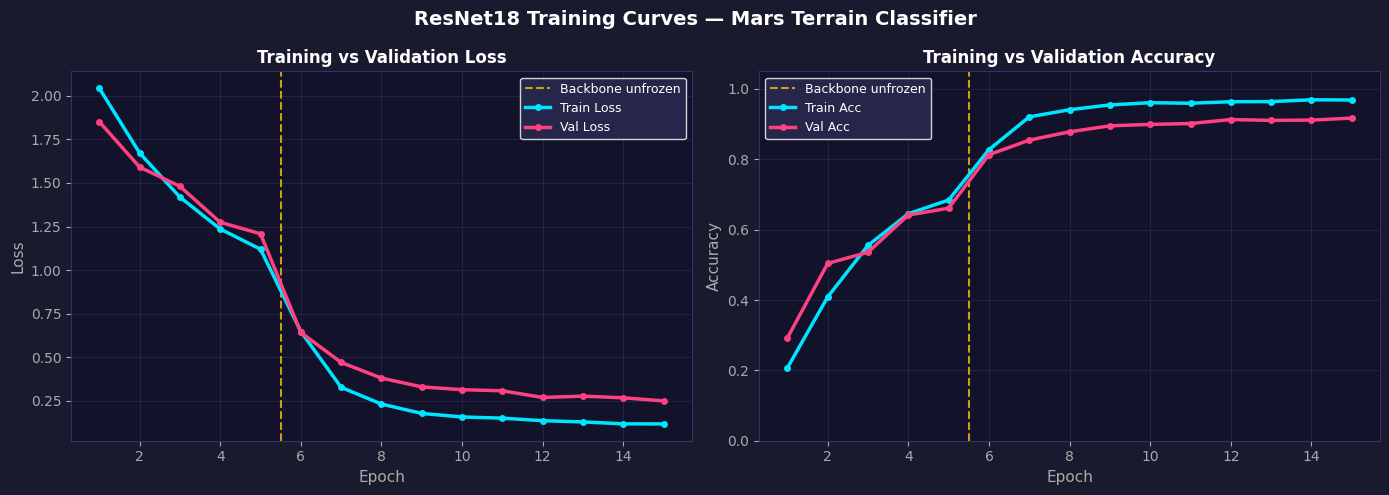

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1A1A2E')
epochs_range = range(1, NUM_EPOCHS + 1)

for ax in [ax1, ax2]:
    ax.set_facecolor('#12122A')
    ax.tick_params(colors='#AAAAAA')
    ax.set_xlabel('Epoch', color='#AAAAAA', fontsize=11)
    ax.grid(True, color='#333366', linewidth=0.5, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333366')
    ax.axvline(x=UNFREEZE_EPOCH + 0.5, color='#FFC107', linestyle='--',
               linewidth=1.5, alpha=0.8, label='Backbone unfrozen')

# Loss
ax1.set_title('Training vs Validation Loss', color='white', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', color='#AAAAAA', fontsize=11)
ax1.plot(epochs_range, history['train_loss'], color='#00E5FF', linewidth=2.5,
         marker='o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   color='#FF4081', linewidth=2.5,
         marker='o', markersize=4, label='Val Loss')
ax1.legend(facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=9)

# Accuracy
ax2.set_title('Training vs Validation Accuracy', color='white', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', color='#AAAAAA', fontsize=11)
ax2.plot(epochs_range, history['train_acc'], color='#00E5FF', linewidth=2.5,
         marker='o', markersize=4, label='Train Acc')
ax2.plot(epochs_range, history['val_acc'],   color='#FF4081', linewidth=2.5,
         marker='o', markersize=4, label='Val Acc')
ax2.set_ylim(0, 1.05)
ax2.legend(facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=9)

fig.suptitle('ResNet18 Training Curves — Mars Terrain Classifier',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Evaluation: Confusion Matrix & Classification Report

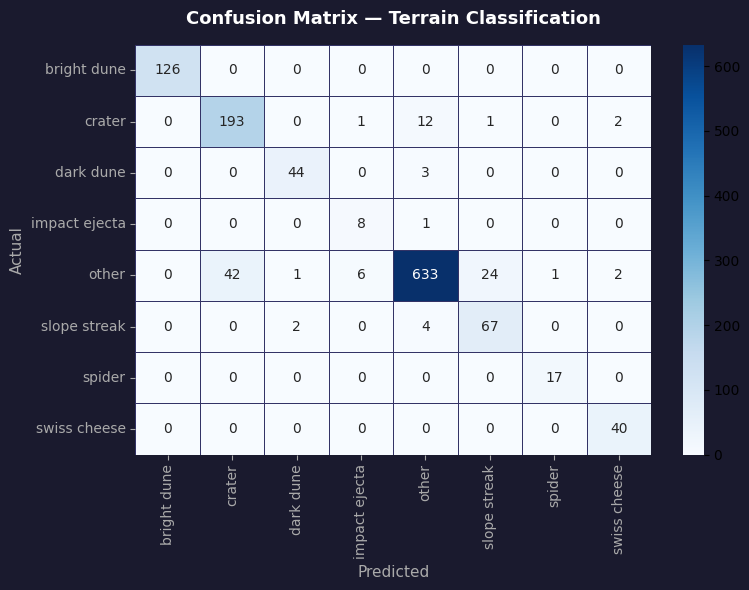


Classification Report:
               precision    recall  f1-score   support

  bright dune       1.00      1.00      1.00       126
       crater       0.82      0.92      0.87       209
    dark dune       0.94      0.94      0.94        47
impact ejecta       0.53      0.89      0.67         9
        other       0.97      0.89      0.93       709
 slope streak       0.73      0.92      0.81        73
       spider       0.94      1.00      0.97        17
 swiss cheese       0.91      1.00      0.95        40

     accuracy                           0.92      1230
    macro avg       0.86      0.94      0.89      1230
 weighted avg       0.93      0.92      0.92      1230

Mean confidence score: 0.8896


In [ ]:
# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_confs = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs   = imgs.to(DEVICE)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        confs, preds = probs.max(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confs.extend(confs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_confs  = np.array(all_confs)

#  Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#1A1A2E')
ax.set_facecolor('#12122A')

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5, linecolor='#333366'
)
ax.set_title('Confusion Matrix — Terrain Classification', color='white',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted', color='#AAAAAA', fontsize=11)
ax.set_ylabel('Actual',    color='#AAAAAA', fontsize=11)
ax.tick_params(colors='#AAAAAA')
plt.tight_layout()
plt.show()

# ── Classification Report ─────────────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
print(f'Mean confidence score: {all_confs.mean():.4f}')


##  Degradation Impact on CNN Accuracy

Testing how CNN classification accuracy drops as sensor degradation increases.



In [ ]:
from PIL import Image

#  Degradation functions (from Notebook 02)
def apply_gaussian_noise(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, severity * 80, frame.shape)
    return np.clip(frame.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def apply_occlusion(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    degraded = frame.copy()
    h, w = frame.shape[:2]
    occ_h, occ_w = int(h * severity * 0.9), int(w * severity * 0.9)
    if occ_h > 0 and occ_w > 0:
        top  = rng.integers(0, max(1, h - occ_h))
        left = rng.integers(0, max(1, w - occ_w))
        degraded[top:top+occ_h, left:left+occ_w] = 160
    return degraded

def apply_dropout(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    degraded = frame.copy()
    mask = rng.random(frame.shape[:2]) < severity
    degraded[mask] = 0
    return degraded


# Inference on a degraded image
def predict_terrain(img_array, model, transform):
    """
    Run CNN inference on a numpy image array.
    Returns predicted class index and confidence score.
    """
    # Convert to PIL for transform pipeline
    if img_array.ndim == 2:
        pil_img = Image.fromarray(img_array).convert('RGB')
    else:
        pil_img = Image.fromarray(img_array)

    tensor = transform(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)
        conf, pred = probs.max(dim=1)

    return pred.item(), conf.item(), probs.cpu().numpy()[0]


# Evaluate accuracy across severity levels
SEVERITY_RANGE  = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
DEGRADATION_FNS = {
    'Gaussian Noise': apply_gaussian_noise,
    'Occlusion':      apply_occlusion,
    'Dropout':        apply_dropout,
}

# Sample validation images for testing
NUM_TEST_IMGS = 100
test_imgs, test_labels_list = [], []

for cls_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATA_ROOT, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    np.random.seed(42)
    samples = np.random.choice(img_files, min(NUM_TEST_IMGS // NUM_CLASSES, len(img_files)), replace=False)
    for fname in samples:
        img = np.array(Image.open(os.path.join(cls_path, fname)).convert('RGB'))
        test_imgs.append(img)
        test_labels_list.append(cls_idx)

print(f'Testing degradation impact on {len(test_imgs)} images...')

degradation_results = {}

for deg_name, deg_fn in DEGRADATION_FNS.items():
    acc_scores, conf_scores = [], []
    for severity in SEVERITY_RANGE:
        correct, total, total_conf = 0, 0, 0
        for img, true_label in zip(test_imgs, test_labels_list):
            if severity > 0:
                degraded = deg_fn(img, severity=severity, seed=42)
            else:
                degraded = img
            pred, conf, _ = predict_terrain(degraded, model, val_transform)
            correct    += int(pred == true_label)
            total_conf += conf
            total      += 1
        acc_scores.append(correct / total)
        conf_scores.append(total_conf / total)
    degradation_results[deg_name] = {'acc': acc_scores, 'conf': conf_scores}
    print(f'  {deg_name}: clean acc={acc_scores[0]:.3f}, severe acc={acc_scores[-1]:.3f}')

print('Done.')

Testing degradation impact on 96 images...
  Gaussian Noise: clean acc=0.979, severe acc=0.125
  Occlusion: clean acc=0.979, severe acc=0.542
  Dropout: clean acc=0.979, severe acc=0.135
Done.



##  Degradation Impact Curves


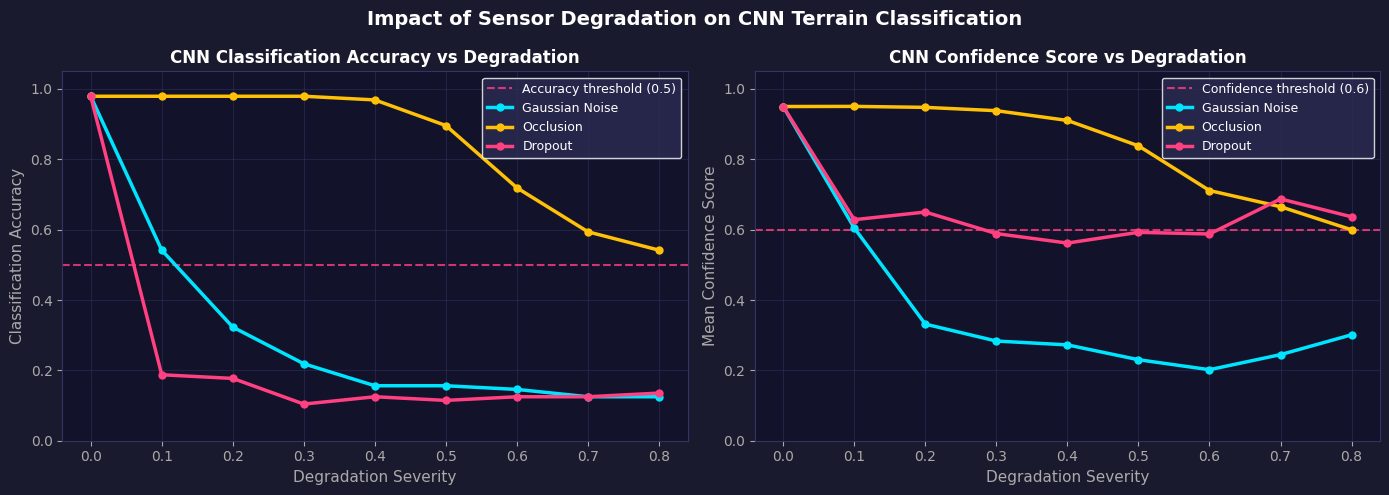

Key insight for dissertation:
As degradation severity increases, both accuracy and confidence drop.
The confidence score can therefore serve as a real-time proxy
for sensor quality — the basis of the Sensor Quality Monitor in Notebook 04.


In [ ]:
CURVE_COLOURS = ['#00E5FF', '#FFC107', '#FF4081']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1A1A2E')

for ax in [ax1, ax2]:
    ax.set_facecolor('#12122A')
    ax.tick_params(colors='#AAAAAA')
    ax.set_xlabel('Degradation Severity', color='#AAAAAA', fontsize=11)
    ax.grid(True, color='#333366', linewidth=0.5, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333366')

# Accuracy curve
ax1.set_title('CNN Classification Accuracy vs Degradation', color='white',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Classification Accuracy', color='#AAAAAA', fontsize=11)
ax1.axhline(y=0.5, color='#FF4081', linestyle='--', linewidth=1.5,
            alpha=0.8, label='Accuracy threshold (0.5)')
for (deg_name, data), colour in zip(degradation_results.items(), CURVE_COLOURS):
    ax1.plot(SEVERITY_RANGE, data['acc'], color=colour, linewidth=2.5,
             marker='o', markersize=5, label=deg_name)
ax1.set_ylim(0, 1.05)
ax1.legend(facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=9)

# Confidence curve
ax2.set_title('CNN Confidence Score vs Degradation', color='white',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Confidence Score', color='#AAAAAA', fontsize=11)
ax2.axhline(y=0.6, color='#FF4081', linestyle='--', linewidth=1.5,
            alpha=0.8, label='Confidence threshold (0.6)')
for (deg_name, data), colour in zip(degradation_results.items(), CURVE_COLOURS):
    ax2.plot(SEVERITY_RANGE, data['conf'], color=colour, linewidth=2.5,
             marker='o', markersize=5, label=deg_name)
ax2.set_ylim(0, 1.05)
ax2.legend(facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=9)

fig.suptitle('Impact of Sensor Degradation on CNN Terrain Classification',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key insight for dissertation:')
print('As degradation severity increases, both accuracy and confidence drop.')
print('The confidence score can therefore serve as a real-time proxy')
print('for sensor quality — the basis of the Sensor Quality Monitor in Notebook 04.')


##  Save Model

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/Mars Rover Project'
os.makedirs(SAVE_DIR, exist_ok=True)

checkpoint = {
    'model_state_dict':  model.state_dict(),
    'class_names':       CLASS_NAMES,
    'num_classes':       NUM_CLASSES,
    'val_accuracy':      best_val_acc,
    'img_size':          IMG_SIZE,
    'imagenet_mean':     IMAGENET_MEAN,
    'imagenet_std':      IMAGENET_STD,
    'terrain_cost_map':  {k: (999 if v == float('inf') else v) for k, v in TERRAIN_COST_MAP.items()},
    'terrain_nav_label': TERRAIN_NAV_LABEL,
}

CHECKPOINT_PATH = os.path.join(SAVE_DIR, 'terrain_classifier.pth')
torch.save(checkpoint, CHECKPOINT_PATH)
print(f'Model saved to {CHECKPOINT_PATH}')
print(f'Classes:           {CLASS_NAMES}')
print(f'Best val accuracy: {best_val_acc*100:.2f}%')
print('Checkpoint saved to Drive — available in all future notebooks.')


Model saved to /content/drive/MyDrive/Colab Notebooks/Mars Rover Project/terrain_classifier.pth
Classes:           ['bright dune', 'crater', 'dark dune', 'impact ejecta', 'other', 'slope streak', 'spider', 'swiss cheese']
Best val accuracy: 91.71%
Checkpoint saved to Drive — available in all future notebooks.
